<h1>AIPD PROJECT</h1>

**Members:**

**Aarya Laxman Gaikwad(EN23107025)**

**Srushti Amar Bhosale(EN23107008)**

**Shreni Navnath Bandgar(EN23107003)**

**Shalaka Bondre(EN23107009)**

**Class:-TY-AIDS(A)**



In [ ]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


In [ ]:
df=pd.read_csv("C:/Users/Shreni/OneDrive/Desktop/AI-Product-Development/aipd/AIPD_PROJECT/dataset/post natal data.csv")

In [ ]:
df

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
print("Missing values before handling:")
print(df.isnull().sum())
print("\nData shape:", df.shape)

In [ ]:
# Fill missing numerical values with median
df = df.fillna(df.median(numeric_only=True))

In [ ]:
print("Data types after preprocessing:")
print(df.dtypes)
print("\nMissing values after fillna:")
print(df.isnull().sum())

In [ ]:
# Ensure no remaining null values after preprocessing
print("Final null check:")
print(df.isnull().sum().sum(), "null values remaining")

In [ ]:


if "Timestamp" in df.columns:
    df.drop("Timestamp", axis=1, inplace=True)


label_encoders = {}

for column in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le



In [ ]:
# Data validation after preprocessing
print("=== Data Validation ===")
print(f"Dataset shape: {df.shape}")
print(f"Data types:\n{df.dtypes}")
print(f"\nNumeric features statistics:")
print(df.describe())
print(f"\nNo null values remaining: {df.isnull().sum().sum() == 0}")

In [ ]:

target_column = "Suicide attempt"   #
X = df.drop(target_column, axis=1)
y = df[target_column]



In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



In [ ]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


<H1>Train Models</H1>








**1) Random Forest**

In [ ]:

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

**2) Decision Tree**

In [ ]:

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
dt_pred = dt.predict(X_test_scaled)


**3) Logistic Regression**

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

**4) Evaluation **

In [ ]:
def evaluate_model(model_name, y_test, y_pred):
    print(f"\n===== {model_name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision (Weighted):", precision_score(y_test, y_pred, average='weighted'))
    print("Recall (Weighted):", recall_score(y_test, y_pred, average='weighted'))
    print("F1 Score (Weighted):", f1_score(y_test, y_pred, average='weighted'))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



**5) Evaluate All Models**



In [ ]:
evaluate_model("Random Forest", y_test, rf_pred)

In [ ]:
evaluate_model("Decision Tree", y_test, dt_pred)

In [ ]:
evaluate_model("Logistic Regression", y_test, lr_pred)


In [ ]:


feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nRandom Forest Feature Importance:")
print(feature_importance)

**visualization**

In [ ]:
sns.pairplot(df)

In [ ]:
sns.histplot(df)

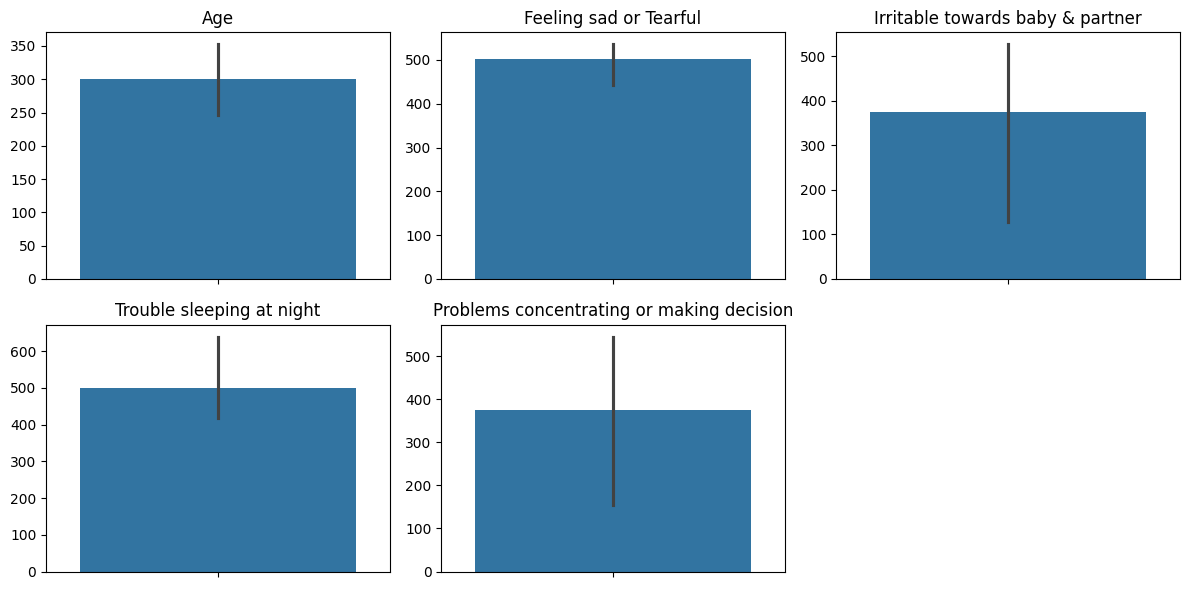

In [35]:
plt.figure(figsize=(12, 6))
# Create bar plot for first few numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns[:5]
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i+1)
    sns.barplot(y=df[col].value_counts().values)
    plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
corr_matrix = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, 
            annot=True,       # show numbers
            cmap="coolwarm",  # color style
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
# Swarm plot - show distribution of first 2 features vs target
numeric_cols = df.select_dtypes(include=[np.number]).columns[:2]
for i, col in enumerate(numeric_cols):
    plt.subplot(1, 2, i+1)
    sns.swarmplot(data=df, x=df.columns[-1], y=col)
    plt.title(f"{col} vs Target")
plt.tight_layout()
plt.show()

In [ ]:
sns.violinplot(df)

In [ ]:
plt.figure(figsize=(12, 6))
# Violin plot for numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns[:5]
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i+1)
    sns.violinplot(data=df, y=col)
    plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
sns.boxplot(df)

In [ ]:
sns.kdeplot(data=df["Age"], fill=True)